In [2]:
import os
print(os.listdir())

['.config', 'heart 2.csv', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
import pandas as pd

df = pd.read_csv('heart 2.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [11]:
X = df.drop('target', axis=1)
y = df['target']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9853658536585366


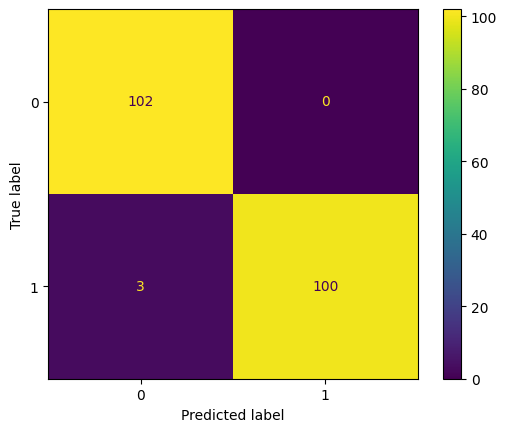

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

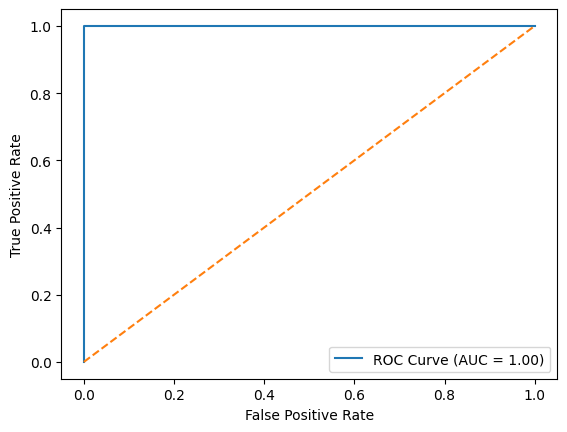

In [17]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.2f)' % roc_auc)

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

In [18]:
print("Heart Disease Prediction Project Completed Successfully")
print("Model Accuracy:", accuracy)

Heart Disease Prediction Project Completed Successfully
Model Accuracy: 0.9853658536585366


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9853658536585366


In [20]:
print("Random Forest Accuracy:", accuracy)
print("Decision Tree Accuracy:", dt_accuracy)

Random Forest Accuracy: 0.9853658536585366
Decision Tree Accuracy: 0.9853658536585366


In [21]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7951219512195122


In [22]:
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)

Decision Tree Accuracy: 0.9853658536585366
Random Forest Accuracy: 0.9853658536585366
Logistic Regression Accuracy: 0.7951219512195122


     Feature  Importance
2         cp    0.133589
11        ca    0.127154
7    thalach    0.120984
12      thal    0.115210
9    oldpeak    0.112555
4       chol    0.081028
0        age    0.079220
3   trestbps    0.068639
8      exang    0.056062
10     slope    0.046344
1        sex    0.028173
6    restecg    0.020703
5        fbs    0.010338


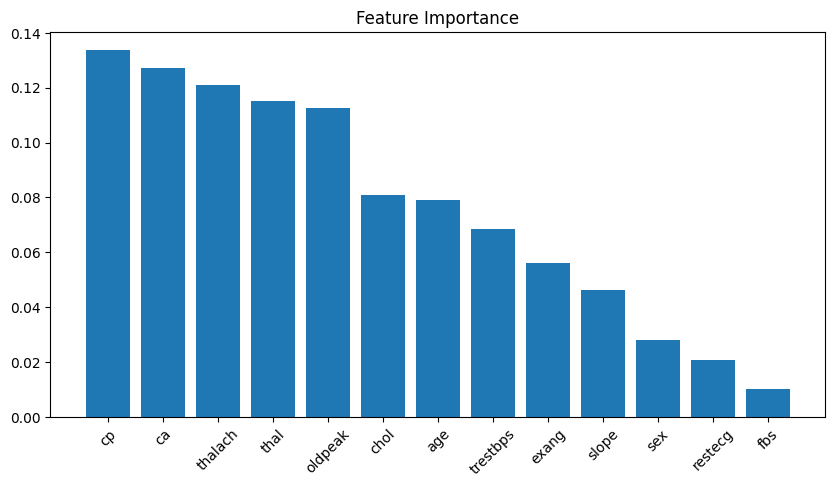

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,5))
plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])
plt.xticks(rotation=45)
plt.title('Feature Importance')
plt.show()